**CAPSTONE** **PROJECT**

In [11]:
# Capstone Project - Pedestrian Road Casualties Analysis
## Group 9: Nicole Wainaina & Emmanuel Juma
### Feature Engineering + Full Analysis
#**Week 7 Focus**: Data Preparation, Cleaning & Feature Engineering

**Import Libraries**

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import glm
from statsmodels.genmod.families import Binomial
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import LabelEncoder

sns.set_style("whitegrid")
print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


**Upload** **Dataset**

In [13]:
from google.colab import files
uploaded = files.upload()

# Load the data
df = pd.read_excel('knbs002-road-accident-casualties-qoabis.xlsx', sheet_name='Sheet1')

# Basic cleaning
df['OBS_VALUE'] = pd.to_numeric(df['OBS_VALUE'], errors='coerce')
df['TIME_PERIOD'] = pd.to_numeric(df['TIME_PERIOD'], errors='coerce')

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print(df.head())

Saving knbs002-road-accident-casualties-qoabis.xlsx to knbs002-road-accident-casualties-qoabis (1).xlsx
Dataset loaded successfully!
Shape: (72, 6)
   TIME_PERIOD GEO       UNIT_MEASURE    ROAD_USER        INJURY_TYPE  \
0         2018  KE  number of people   Pedestrians             Killed   
1         2018  KE  number of people   Pedestrians  Seriously Injured   
2         2018  KE  number of people   Pedestrians   Slightly Injured   
3         2018  KE  number of people       Drivers             Killed   
4         2018  KE  number of people       Drivers  Seriously Injured   

   OBS_VALUE  
0       1205  
1        851  
2        256  
3        306  
4        496  


**Feature** **Engineering**

In [14]:
print("🔧 Starting Feature Engineering...")

# 1. Create Total Casualties per Year & Road User
df_grouped = df.groupby(['TIME_PERIOD', 'ROAD_USER', 'INJURY_TYPE'])['OBS_VALUE'].sum().reset_index()

# 2. Pivot to wide format for easier analysis
df_pivot = df_grouped.pivot_table(index=['TIME_PERIOD', 'ROAD_USER'],
                                  columns='INJURY_TYPE',
                                  values='OBS_VALUE',
                                  fill_value=0).reset_index()

# Rename columns for clarity
df_pivot = df_pivot.rename(columns={
    'Killed': 'KILLED',
    'Seriously Injured': 'SERIOUSLY_INJURED',
    'Slightly Injured': 'SLIGHTLY_INJURED'
})

# 3. Derived Features (Core Feature Engineering)
df_pivot['TOTAL_CASUALTIES'] = (df_pivot['KILLED'] +
                                df_pivot['SERIOUSLY_INJURED'] +
                                df_pivot['SLIGHTLY_INJURED'])

df_pivot['FATALITY_RATE'] = (df_pivot['KILLED'] / df_pivot['TOTAL_CASUALTIES'] * 100).round(2)

df_pivot['SERIOUS_INJURY_RATE'] = (df_pivot['SERIOUSLY_INJURED'] / df_pivot['TOTAL_CASUALTIES'] * 100).round(2)

# 4. Pedestrian-Specific Flags and Features
df_pivot['IS_PEDESTRIAN'] = (df_pivot['ROAD_USER'] == 'Pedestrians').astype(int)

# 5. Vulnerability Index (New engineered feature)
# Combines fatality rate and proportion of serious injuries
df_pivot['VULNERABILITY_INDEX'] = (df_pivot['FATALITY_RATE'] * 0.7 +
                                   df_pivot['SERIOUS_INJURY_RATE'] * 0.3).round(2)

# 6. Year as numeric for modeling
df_pivot['YEAR'] = df_pivot['TIME_PERIOD']

print("✅ Feature Engineering Completed!")
print("\nNew Engineered Features:")
print(df_pivot.columns.tolist())
print("\nSample of engineered data:")
print(df_pivot.head())

🔧 Starting Feature Engineering...
✅ Feature Engineering Completed!

New Engineered Features:
['TIME_PERIOD', 'ROAD_USER', 'KILLED', 'SERIOUSLY_INJURED', 'SLIGHTLY_INJURED', 'TOTAL_CASUALTIES', 'FATALITY_RATE', 'SERIOUS_INJURY_RATE', 'IS_PEDESTRIAN', 'VULNERABILITY_INDEX', 'YEAR']

Sample of engineered data:
INJURY_TYPE  TIME_PERIOD      ROAD_USER  KILLED  SERIOUSLY_INJURED  \
0                   2018        Drivers   306.0              496.0   
1                   2018  Motor Cyclist   591.0              698.0   
2                   2018     Passengers   746.0             2093.0   
3                   2018  Pedal Cyclist    63.0               36.0   
4                   2018    Pedestrians  1205.0              851.0   

INJURY_TYPE  SLIGHTLY_INJURED  TOTAL_CASUALTIES  FATALITY_RATE  \
0                       307.0            1109.0          27.59   
1                       184.0            1473.0          40.12   
2                      4087.0            6926.0          10.77   
3     

**Exploratory** **Data** **Analysis** (**EDA**) **after** **Feature** **Engineering**

/tmp/ipykernel_13558/2040058249.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ped_share, x='YEAR', y='PED_SHARE_%', palette='Blues_d')


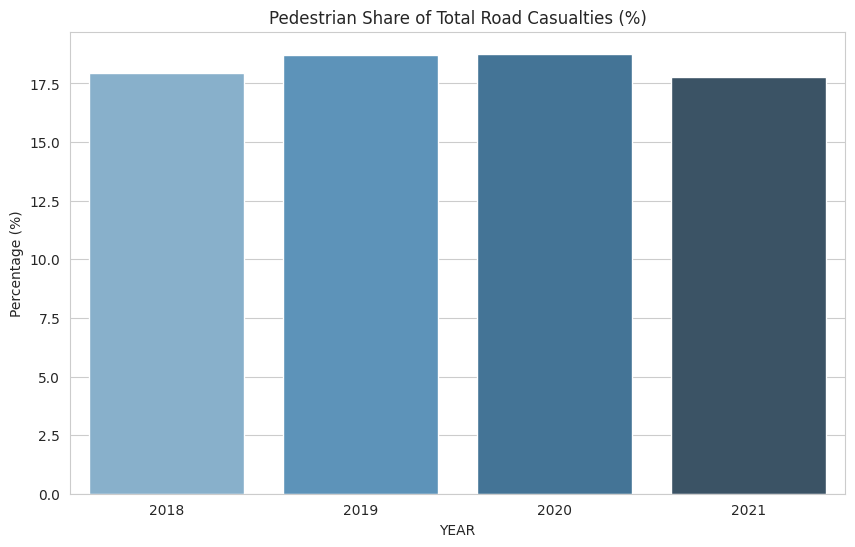

In [15]:
# Pedestrian Share Analysis
total_casualties_year = df_pivot.groupby('YEAR')['TOTAL_CASUALTIES'].sum().reset_index()
pedestrian_data = df_pivot[df_pivot['ROAD_USER'] == 'Pedestrians']

ped_share = pd.merge(total_casualties_year,
                     pedestrian_data[['YEAR', 'TOTAL_CASUALTIES']],
                     on='YEAR', suffixes=('_total', '_ped'))

ped_share['PED_SHARE_%'] = (ped_share['TOTAL_CASUALTIES_ped'] / ped_share['TOTAL_CASUALTIES_total'] * 100).round(2)

# Visualisation
plt.figure(figsize=(10, 6))
sns.barplot(data=ped_share, x='YEAR', y='PED_SHARE_%', palette='Blues_d')
plt.title('Pedestrian Share of Total Road Casualties (%)')
plt.ylabel('Percentage (%)')
plt.show()

**Fatality** **Rate** **Visualisation**

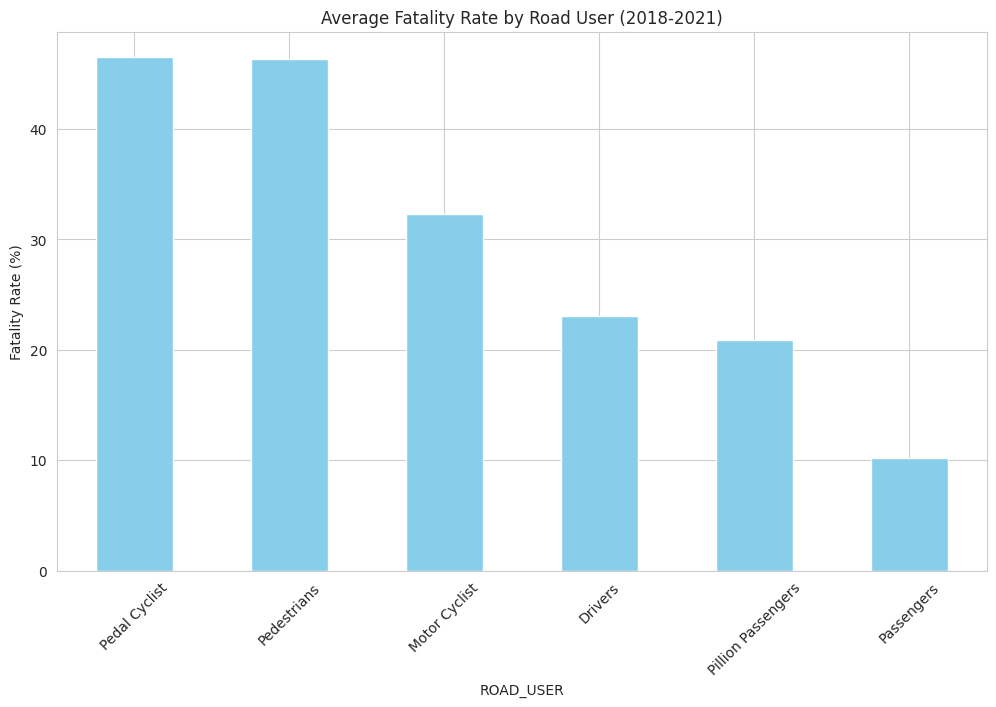

ROAD_USER
Pedal Cyclist         46.4875
Pedestrians           46.2850
Motor Cyclist         32.3125
Drivers               23.0450
Pillion Passengers    20.8750
Passengers            10.2300
Name: FATALITY_RATE, dtype: float64


In [22]:
# Fatality Rate by Road User
fatality_summary = df_pivot.groupby('ROAD_USER')['FATALITY_RATE'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 7))
fatality_summary.plot(kind='bar', color='skyblue')
plt.title('Average Fatality Rate by Road User (2018-2021)')
plt.ylabel('Fatality Rate (%)')
plt.xticks(rotation=45)
plt.show()

print(fatality_summary)

**Linear** **Regression** **on** **Pedestrian** **Casualties**

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 4 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


                            OLS Regression Results                            
Dep. Variable:       TOTAL_CASUALTIES   R-squared:                       0.972
Model:                            OLS   Adj. R-squared:                  0.957
Method:                 Least Squares   F-statistic:                     68.28
Date:                Wed, 01 Apr 2026   Prob (F-statistic):             0.0143
Time:                        20:04:39   Log-Likelihood:                -23.317
No. Observations:                   4   AIC:                             50.63
Df Residuals:                       2   BIC:                             49.41
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -8.656e+05   1.05e+05     -8.234      0.0

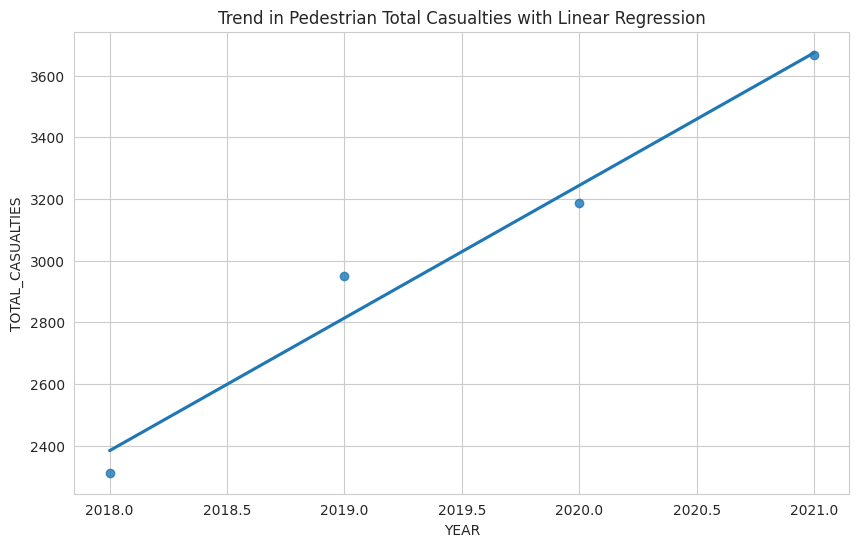

In [23]:
# Linear Regression for Trend
ped_data = pedestrian_data[['YEAR', 'TOTAL_CASUALTIES']].copy()
X = sm.add_constant(ped_data['YEAR'])
y = ped_data['TOTAL_CASUALTIES']

model = sm.OLS(y, X).fit()
print(model.summary())

# Plot Trend
plt.figure(figsize=(10, 6))
sns.regplot(x='YEAR', y='TOTAL_CASUALTIES', data=ped_data, ci=None)
plt.title('Trend in Pedestrian Total Casualties with Linear Regression')
plt.show()

**Binomial Logistic Regression**

In [26]:
# Prepare data for logistic regression (binomial)
df_model = df_pivot.copy()
df_model = pd.get_dummies(df_model, columns=['ROAD_USER'], drop_first=True, prefix='USER')

# Select features
X = df_model[['YEAR'] + [col for col in df_model.columns if col.startswith('USER_')]]
X = sm.add_constant(X)

# Convert all columns in X to numeric (float) to handle boolean dummy variables
X = X.astype(float)

# Endog for binomial: successes (killed) and failures (survived)
endog = np.column_stack((df_model['KILLED'], df_model['TOTAL_CASUALTIES'] - df_model['KILLED']))

logit_model = sm.GLM(endog, X, family=Binomial()).fit()
print(logit_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:           ['y1', 'y2']   No. Observations:                   24
Model:                            GLM   Df Residuals:                       17
Model Family:                Binomial   Df Model:                            6
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -133.41
Date:                Wed, 01 Apr 2026   Deviance:                       85.011
Time:                        20:06:50   Pearson chi2:                     85.5
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

**Arima Forecasting**

In [27]:
# ARIMA on Pedestrian Killed
ped_killed = df[(df['ROAD_USER'] == 'Pedestrians') & (df['INJURY_TYPE'] == 'Killed')]
ped_killed_ts = ped_killed.groupby('TIME_PERIOD')['OBS_VALUE'].sum()

arima_model = ARIMA(ped_killed_ts, order=(1, 1, 0))
arima_fit = arima_model.fit()
forecast = arima_fit.forecast(steps=2)

print("🚀 ARIMA Forecast for Pedestrian Killed:")
print("2022:", round(forecast.iloc[0], 0))
print("2023:", round(forecast.iloc[1], 0))

🚀 ARIMA Forecast for Pedestrian Killed:
2022: 1575.0
2023: 1577.0


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be give

In [28]:
# Save the engineered dataset for future use
df_pivot.to_excel('engineered_road_casualties.xlsx', index=False)
files.download('engineered_road_casualties.xlsx')
print("✅ Engineered dataset downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Engineered dataset downloaded!
